# Nigerian House Price Prediction with PyTorch
### A Prodigy Training Hub Masterclass — Real Estate Edition

This notebook builds an end-to-end **regression** model that predicts the **sale price of a residential property** in Nigeria (in Naira) from 50+ features covering location, structure, land area, amenities, infrastructure, and transaction context.

This is the **regression companion** to the classification projects (loan risk and churn) — predicting a **continuous number** rather than a category, with `nn.MSELoss` instead of `nn.CrossEntropyLoss` or `nn.BCEWithLogitsLoss`.

**Key differences from classification notebooks:**

| Aspect | Classification (Churn / Loan Risk) | Regression (House Price) |
|---|---|---|
| Target | Discrete class index | Continuous real number |
| Loss function | BCEWithLogitsLoss / CrossEntropyLoss | MSELoss |
| Output neurons | 1 (binary) or 4 (4-class) | 1 (predicted price) |
| Evaluation metrics | Accuracy, F1, AUC | RMSE, MAE, R², MAPE |
| Final activation | None (raw logit) | None (raw price) |
| Target scaling | Not needed | **Critical** — prices span billions of Naira |

**Dataset:** `nigerian_house_price_dataset.csv` / `.xlsx` — 12,000 synthetic but realistically-structured Nigerian residential properties across Lagos, Abuja, Port Harcourt, and other major cities.

---


## 0. Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("PyTorch version:", torch.__version__)
print("Device         :", device)

def format_naira(value, pos=None):
    """Matplotlib ticker formatter for Naira (millions / billions)."""
    if abs(value) >= 1e9:
        return f"₦{value/1e9:.1f}B"
    elif abs(value) >= 1e6:
        return f"₦{value/1e6:.0f}M"
    else:
        return f"₦{value/1e3:.0f}K"


PyTorch version: 2.12.1+cu130
Device         : cpu


## 1. Loading and First Look

In [2]:
df = pd.read_csv("nigerian_house_price_dataset.csv")
print("Shape:", df.shape)
print("\nFirst 3 rows:")
df.head(3)


Shape: (12000, 56)

First 3 rows:


,property_id,city_location,state,region,zone_type,in_estate,estate_name,property_type,bedrooms,bathrooms,...,flood_risk,listing_year,days_on_market,agent_tier,negotiation_discount_pct,neighborhood_price_index_per_sqm,listing_type,listed_asking_price_naira,sale_price_naira,price_per_sqm_naira
0,PH100000,Port Harcourt - Diobu / Rumuola,Rivers,South South,Residential Low-Density,0,Not in Estate,Semi-Detached Bungalow,2,1,...,Low,2023,137.0,Mid-Tier Agency,12.5,104000,For Rent,111410000,101170000,464083
1,PH100001,Lagos - Mainland (other),Lagos,South West,Residential High-Density,0,Not in Estate,Semi-Detached Duplex,6,6,...,Medium,2024,86.0,Independent Agent,1.8,25000,Sale,7100000,6990000,233000
2,PH100002,Ibadan - Bodija / Agodi,Oyo,South West,Residential Mid-Range,1,Royal Gardens,Semi-Detached Bungalow,1,1,...,High,2024,89.0,Mid-Tier Agency,16.9,211000,Sale,354450000,291690000,707985


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 56 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   property_id                       12000 non-null  str    
 1   city_location                     12000 non-null  str    
 2   state                             12000 non-null  str    
 3   region                            12000 non-null  str    
 4   zone_type                         12000 non-null  str    
 5   in_estate                         12000 non-null  int64  
 6   estate_name                       12000 non-null  str    
 7   property_type                     12000 non-null  str    
 8   bedrooms                          12000 non-null  int64  
 9   bathrooms                         12000 non-null  int64  
 10  toilets                           12000 non-null  int64  
 11  living_rooms                      12000 non-null  int64  
 12  dining_rooms   

In [4]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing)
print(f"\nTotal missing: {missing.sum()} / {df.shape[0]*df.shape[1]} cells ({missing.sum()/(df.shape[0]*df.shape[1])*100:.3f}%)")


Columns with missing values:
days_on_market           240
dist_to_waterfront_km    215
floor_of_unit            180
setback_metres           144
year_built               120
frontage_metres          120
dtype: int64

Total missing: 1019 / 672000 cells (0.152%)


In [5]:
# Numeric summary
df.describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
in_estate,12000.0,7.100000e-01,4.500000e-01,0.0,0.000000e+00,1.0,1.000000e+00,1.000000e+00
bedrooms,12000.0,3.790000e+00,1.430000e+00,1.0,3.000000e+00,4.0,5.000000e+00,7.000000e+00
bathrooms,12000.0,3.360000e+00,1.470000e+00,1.0,2.000000e+00,3.0,4.000000e+00,7.000000e+00
toilets,12000.0,3.910000e+00,1.550000e+00,1.0,3.000000e+00,4.0,5.000000e+00,8.000000e+00
living_rooms,12000.0,2.210000e+00,8.700000e-01,1.0,2.000000e+00,2.0,3.000000e+00,4.000000e+00
dining_rooms,12000.0,9.400000e-01,5.900000e-01,0.0,1.000000e+00,1.0,1.000000e+00,2.000000e+00
study_rooms,12000.0,5.500000e-01,6.700000e-01,0.0,0.000000e+00,0.0,1.000000e+00,2.000000e+00
boys_quarters,12000.0,8.700000e-01,6.500000e-01,0.0,0.000000e+00,1.0,1.000000e+00,2.000000e+00
parking_spaces,12000.0,3.130000e+00,1.240000e+00,0.0,2.000000e+00,3.0,4.000000e+00,6.000000e+00
total_floors,12000.0,2.190000e+00,1.060000e+00,1.0,1.000000e+00,2.0,3.000000e+00,5.000000e+00


## 2. Exploring the Target Variable: `sale_price_naira`

Sale Price (₦) Summary:
  Min      : ₦         3,850,000
  25th pct : ₦       123,510,000
  Median   : ₦       329,630,000
  Mean     : ₦       787,423,971
  75th pct : ₦       965,022,500
  Max      : ₦     3,500,000,000
  Std Dev  : ₦     1,016,162,360
  Skewness :               1.690  (>0 = right-skewed)


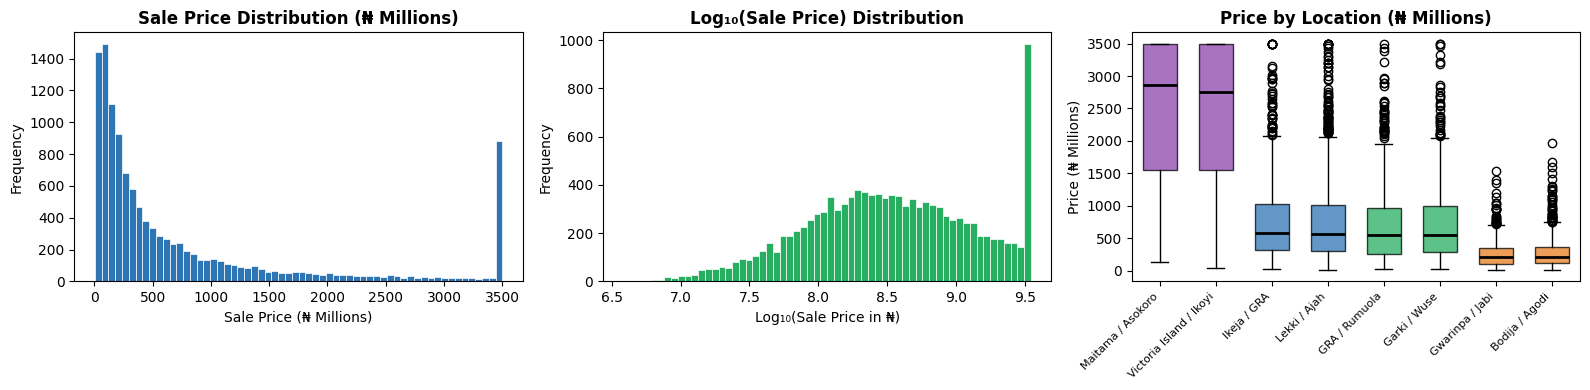

In [6]:
price = df["sale_price_naira"]
print("Sale Price (₦) Summary:")
print(f"  Min      : ₦{price.min():>18,.0f}")
print(f"  25th pct : ₦{price.quantile(0.25):>18,.0f}")
print(f"  Median   : ₦{price.median():>18,.0f}")
print(f"  Mean     : ₦{price.mean():>18,.0f}")
print(f"  75th pct : ₦{price.quantile(0.75):>18,.0f}")
print(f"  Max      : ₦{price.max():>18,.0f}")
print(f"  Std Dev  : ₦{price.std():>18,.0f}")
print(f"  Skewness : {price.skew():>19.3f}  (>0 = right-skewed)")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Raw price histogram
axes[0].hist(price / 1e6, bins=60, color="#2E75B6", edgecolor="white", linewidth=0.5)
axes[0].set_title("Sale Price Distribution (₦ Millions)", fontweight="bold")
axes[0].set_xlabel("Sale Price (₦ Millions)")
axes[0].set_ylabel("Frequency")

# Log-transformed
axes[1].hist(np.log10(price), bins=60, color="#27AE60", edgecolor="white", linewidth=0.5)
axes[1].set_title("Log₁₀(Sale Price) Distribution", fontweight="bold")
axes[1].set_xlabel("Log₁₀(Sale Price in ₦)")
axes[1].set_ylabel("Frequency")

# Box plot by city tier
city_order = df.groupby("city_location")["sale_price_naira"].median().sort_values(ascending=False).index
city_prices = [df.loc[df["city_location"]==c, "sale_price_naira"].values / 1e6 for c in city_order[:8]]
bp = axes[2].boxplot(city_prices, patch_artist=True, widths=0.6,
                      medianprops={"color":"black","linewidth":2})
colors = ["#8E44AD","#8E44AD","#2E75B6","#2E75B6","#27AE60","#27AE60","#E67E22","#E67E22"]
for patch, col in zip(bp["boxes"], colors[:len(city_prices)]):
    patch.set_facecolor(col); patch.set_alpha(0.75)
axes[2].set_xticks(range(1, len(city_prices)+1))
axes[2].set_xticklabels([c.split(" - ")[-1] for c in city_order[:8]], rotation=45, ha="right", fontsize=8)
axes[2].set_title("Price by Location (₦ Millions)", fontweight="bold")
axes[2].set_ylabel("Price (₦ Millions)")

plt.tight_layout()
plt.show()


**Why the target is right-skewed and why we log-transform it:**

The raw price histogram is extremely right-skewed — a handful of properties in Victoria Island / Ikoyi and Maitama are worth billions, pulling the tail far to the right. If we train the neural network to directly predict ₦ values:

1. The MSE loss would be dominated by the few billion-Naira luxury properties, causing the model to optimise heavily for those while performing poorly on the 75% of properties below ₦1 billion.
2. Gradients would be enormous for high-value properties and tiny for low-value ones, creating numerical instability.

**The standard fix:** predict `log10(price)` instead of raw price. The log-transformed distribution (centre panel) is approximately bell-shaped — symmetric, with a mean around log₁₀(₦329M) ≈ 8.5. After training, predictions are un-transformed with `10^(predicted_log_price)`. This is the standard practice in real estate and financial regression modelling.


In [7]:
# Price by location tier — median table
location_summary = df.groupby("city_location")["sale_price_naira"].agg(
    Count="count",
    Median=lambda x: f"₦{x.median()/1e6:,.1f}M",
    Mean=lambda x:   f"₦{x.mean()/1e6:,.1f}M",
    Min=lambda x:    f"₦{x.min()/1e6:,.1f}M",
    Max=lambda x:    f"₦{x.max()/1e6:,.1f}M"
)
print("Price Statistics by Location:")
print(location_summary.to_string())


Price Statistics by Location:
                                 Count     Median       Mean      Min        Max
city_location                                                                   
Abuja - Garki / Wuse               714    ₦553.4M    ₦734.7M   ₦23.3M  ₦3,500.0M
Abuja - Gwarinpa / Jabi            605    ₦204.0M    ₦263.2M    ₦8.5M  ₦1,542.0M
Abuja - Maitama / Asokoro          950  ₦2,861.1M  ₦2,500.0M  ₦129.9M  ₦3,500.0M
Abuja - Outskirts                  500    ₦102.2M    ₦141.8M    ₦6.6M  ₦1,340.7M
Benin City - GRA / Ring Road       455    ₦110.5M    ₦140.1M    ₦5.2M  ₦1,452.0M
Enugu - GRA / Independence         485    ₦203.2M    ₦269.1M    ₦7.8M  ₦1,998.0M
Ibadan - Bodija / Agodi            596    ₦203.4M    ₦283.9M   ₦13.5M  ₦1,966.7M
Kano - GRA / Nassarawa             453    ₦106.9M    ₦136.0M    ₦3.9M  ₦1,353.5M
Lagos - Ikeja / GRA               1093    ₦578.5M    ₦742.6M   ₦17.4M  ₦3,500.0M
Lagos - Lekki / Ajah              1498    ₦570.1M    ₦756.5M   ₦14.9M  ₦3,500.0

## 3. Exploring Price Drivers: Structural Features

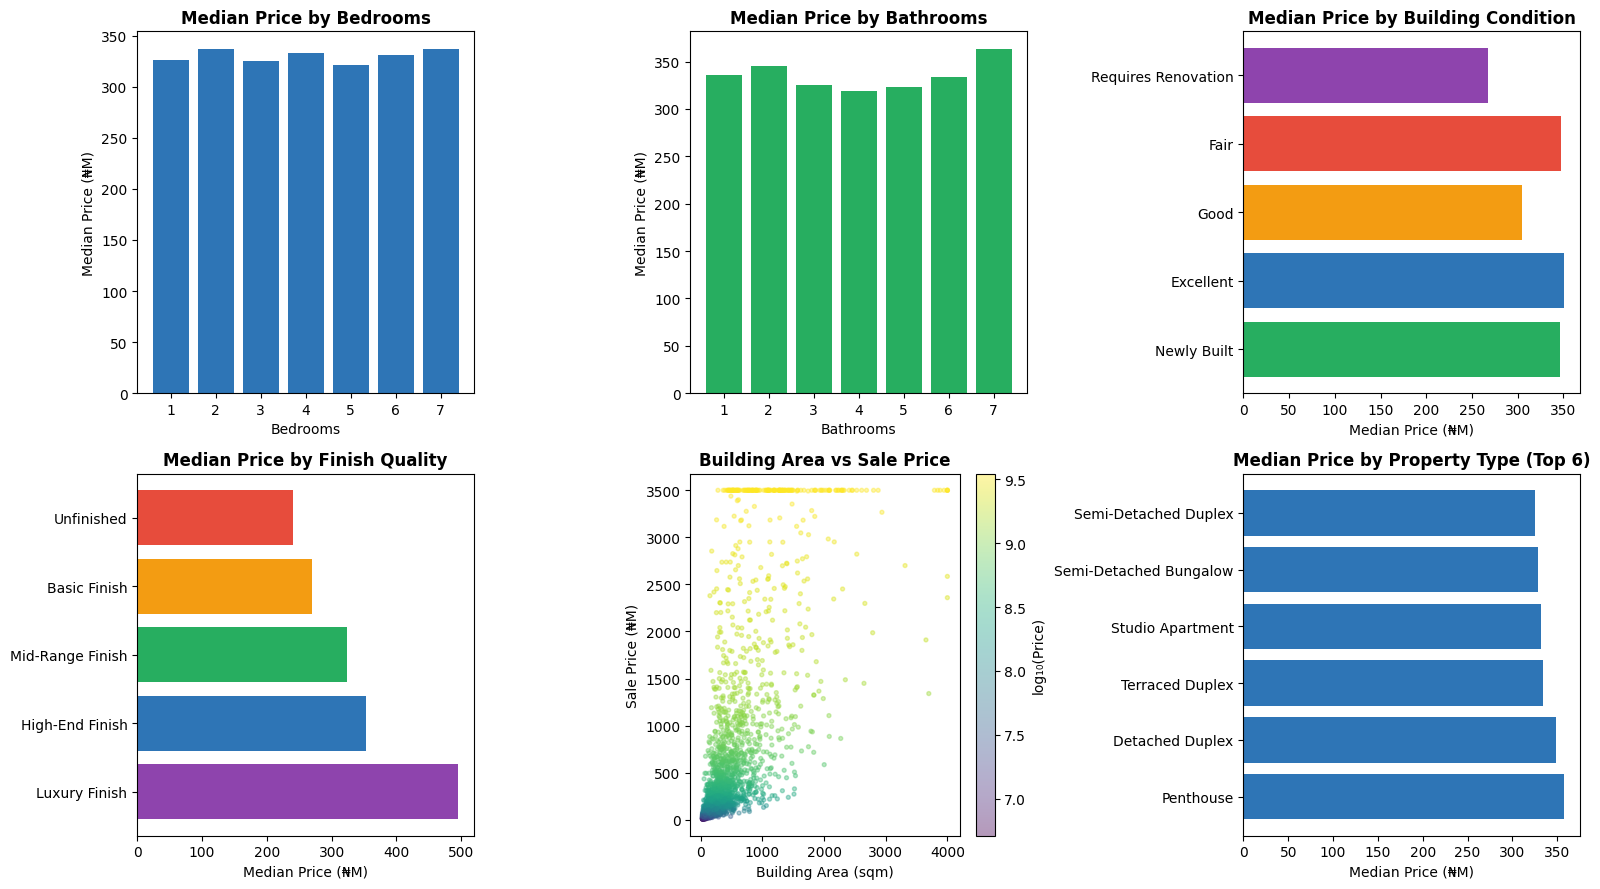

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

# Price vs Bedrooms
bed_medians = df.groupby("bedrooms")["sale_price_naira"].median() / 1e6
axes[0].bar(bed_medians.index, bed_medians.values, color="#2E75B6")
axes[0].set_title("Median Price by Bedrooms", fontweight="bold")
axes[0].set_xlabel("Bedrooms"); axes[0].set_ylabel("Median Price (₦M)")

# Price vs Bathrooms
bath_medians = df.groupby("bathrooms")["sale_price_naira"].median() / 1e6
axes[1].bar(bath_medians.index, bath_medians.values, color="#27AE60")
axes[1].set_title("Median Price by Bathrooms", fontweight="bold")
axes[1].set_xlabel("Bathrooms"); axes[1].set_ylabel("Median Price (₦M)")

# Price vs Building Condition
cond_order = ["Newly Built","Excellent","Good","Fair","Requires Renovation"]
cond_medians = df.groupby("building_condition")["sale_price_naira"].median().reindex(cond_order) / 1e6
axes[2].barh(cond_order, cond_medians, color=["#27AE60","#2E75B6","#F39C12","#E74C3C","#8E44AD"])
axes[2].set_title("Median Price by Building Condition", fontweight="bold")
axes[2].set_xlabel("Median Price (₦M)")

# Price vs Finish Quality
qual_order = ["Luxury Finish","High-End Finish","Mid-Range Finish","Basic Finish","Unfinished"]
qual_medians = df.groupby("finish_quality")["sale_price_naira"].median().reindex(qual_order) / 1e6
axes[3].barh(qual_order, qual_medians, color=["#8E44AD","#2E75B6","#27AE60","#F39C12","#E74C3C"])
axes[3].set_title("Median Price by Finish Quality", fontweight="bold")
axes[3].set_xlabel("Median Price (₦M)")

# Scatter: Building Area vs Price
sample = df.sample(2000, random_state=42)
scatter = axes[4].scatter(sample["building_area_sqm"], sample["sale_price_naira"]/1e6,
                           c=np.log10(sample["sale_price_naira"]), cmap="viridis", alpha=0.4, s=8)
axes[4].set_title("Building Area vs Sale Price", fontweight="bold")
axes[4].set_xlabel("Building Area (sqm)"); axes[4].set_ylabel("Sale Price (₦M)")
plt.colorbar(scatter, ax=axes[4], label="log₁₀(Price)")

# Price vs Property Type (top 6)
top_types = df.groupby("property_type")["sale_price_naira"].median().sort_values(ascending=False).head(6)
axes[5].barh(top_types.index, top_types.values/1e6, color="#2E75B6")
axes[5].set_title("Median Price by Property Type (Top 6)", fontweight="bold")
axes[5].set_xlabel("Median Price (₦M)")

plt.tight_layout()
plt.show()


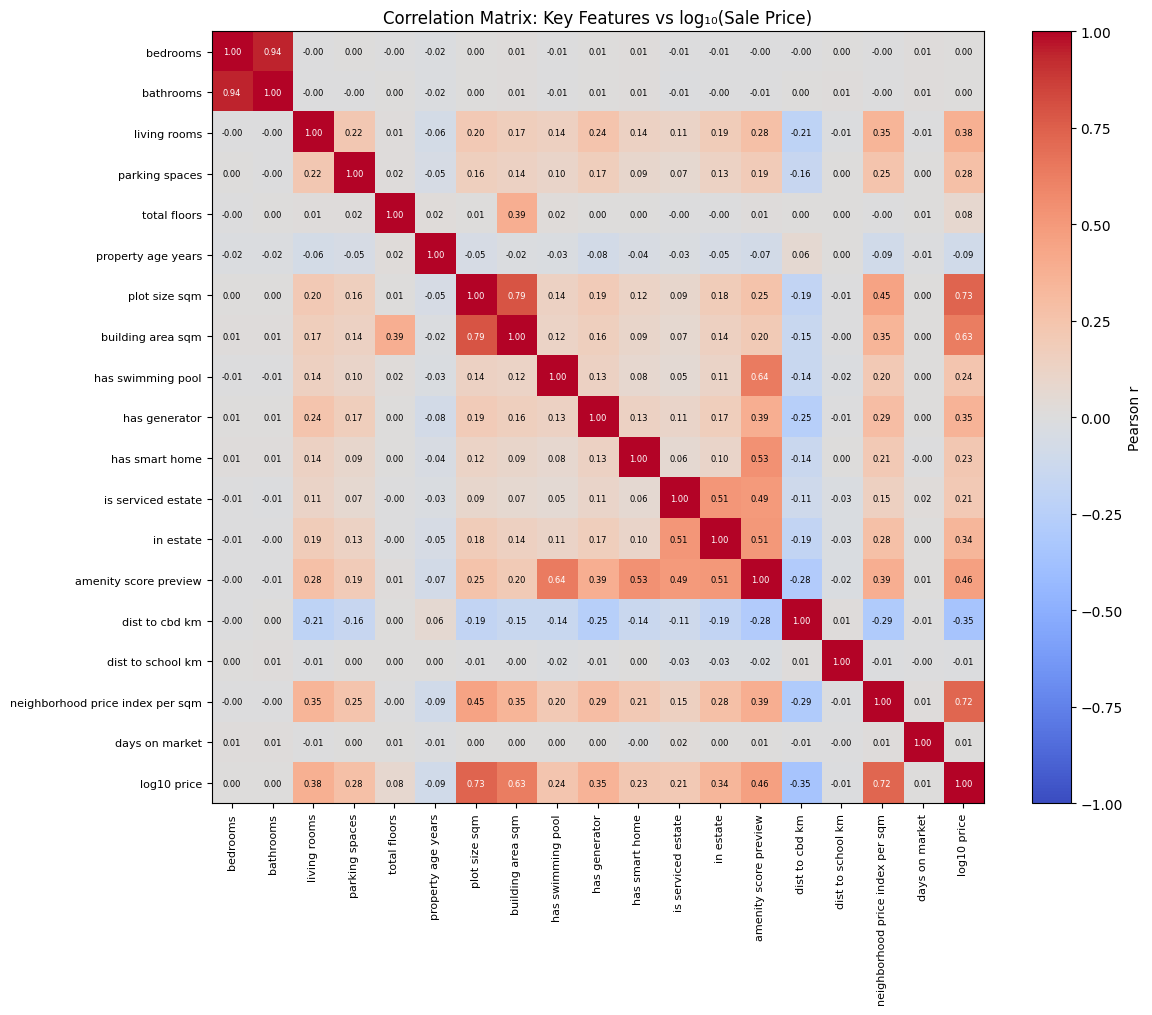

In [9]:
# Correlation heatmap — numeric features vs log price
df["log10_price"] = np.log10(df["sale_price_naira"])
numeric_for_corr = [
    "bedrooms","bathrooms","living_rooms","parking_spaces","total_floors",
    "property_age_years","plot_size_sqm","building_area_sqm",
    "has_swimming_pool","has_generator","has_smart_home","is_serviced_estate",
    "in_estate","amenity_score_preview",
    "dist_to_cbd_km","dist_to_school_km",
    "neighborhood_price_index_per_sqm","days_on_market","log10_price"
]

# Compute amenity score for the heatmap
df["amenity_score_preview"] = (
    df["has_swimming_pool"]*5 + df["has_gym"]*3 + df["has_generator"]*2 +
    df["has_smart_home"]*4 + df["is_serviced_estate"]*3 + df["in_estate"]*2
)

corr = df[numeric_for_corr].corr()

plt.figure(figsize=(12, 10))
im = plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, label="Pearson r")
labels = [c.replace("_"," ").replace("naira","(₦)") for c in numeric_for_corr]
plt.xticks(range(len(labels)), labels, rotation=90, fontsize=8)
plt.yticks(range(len(labels)), labels, fontsize=8)
for i in range(len(numeric_for_corr)):
    for j in range(len(numeric_for_corr)):
        plt.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center",
                  color="white" if abs(corr.iloc[i,j])>0.55 else "black", fontsize=6)
plt.title("Correlation Matrix: Key Features vs log₁₀(Sale Price)")
plt.tight_layout()
plt.show()
df.drop(columns=["amenity_score_preview","log10_price"], inplace=True)


## 4. Amenities and Infrastructure Analysis

Price Premium for Binary Amenities:
           feature  Premium_%  N_with  Median_with_M  Median_without_M
         Generator      259.7    9991          431.5             120.0
  Air Conditioning      212.9    8498          481.8             154.0
         In Estate      204.4    8503          473.2             155.5
          Borehole      195.4    9624          425.3             144.0
              Cctv      185.2    7332          519.9             182.3
    Internet Fiber      151.9    6592          520.6             206.7
     Swimming Pool      119.4    4641          539.6             246.0
        Smart Home      116.1    4553          534.8             247.5
      Solar Panels      105.9    5100          503.0             244.4
Is Serviced Estate      101.8    4657          508.9             252.2
               Gym       83.2    4317          484.2             264.2


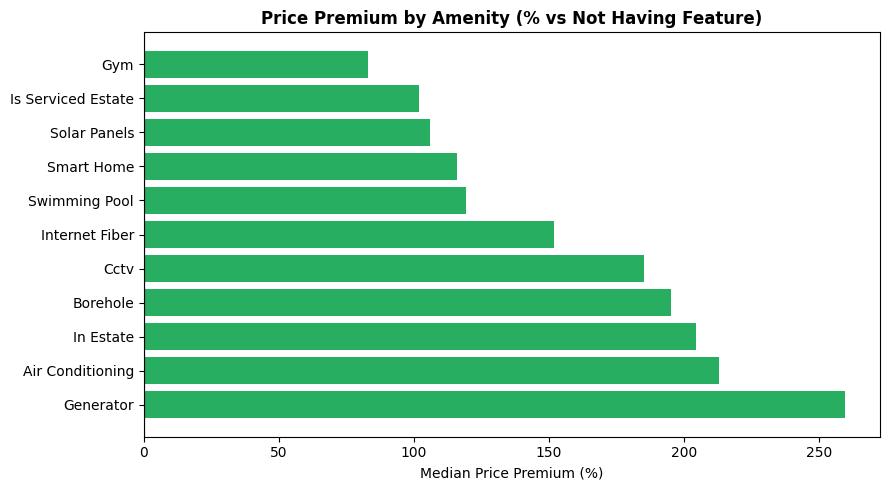

In [10]:
# Price premium for binary amenities
amenity_cols = ["has_swimming_pool","has_gym","has_generator","has_borehole",
                 "has_solar_panels","has_cctv","has_smart_home","is_serviced_estate",
                 "in_estate","has_internet_fiber","has_air_conditioning"]

premium_data = []
for col in amenity_cols:
    yes_med = df.loc[df[col]==1, "sale_price_naira"].median() / 1e6
    no_med  = df.loc[df[col]==0, "sale_price_naira"].median() / 1e6
    premium_pct = (yes_med - no_med) / no_med * 100 if no_med > 0 else 0
    n_yes = (df[col]==1).sum()
    premium_data.append({"feature": col.replace("has_","").replace("_"," ").title(),
                          "Premium_%": round(premium_pct,1), "N_with": n_yes,
                          "Median_with_M": round(yes_med,1), "Median_without_M": round(no_med,1)})

prem_df = pd.DataFrame(premium_data).sort_values("Premium_%", ascending=False)
print("Price Premium for Binary Amenities:")
print(prem_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#27AE60" if p > 0 else "#E74C3C" for p in prem_df["Premium_%"]]
ax.barh(prem_df["feature"], prem_df["Premium_%"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Median Price Premium (%)")
ax.set_title("Price Premium by Amenity (% vs Not Having Feature)", fontweight="bold")
plt.tight_layout()
plt.show()


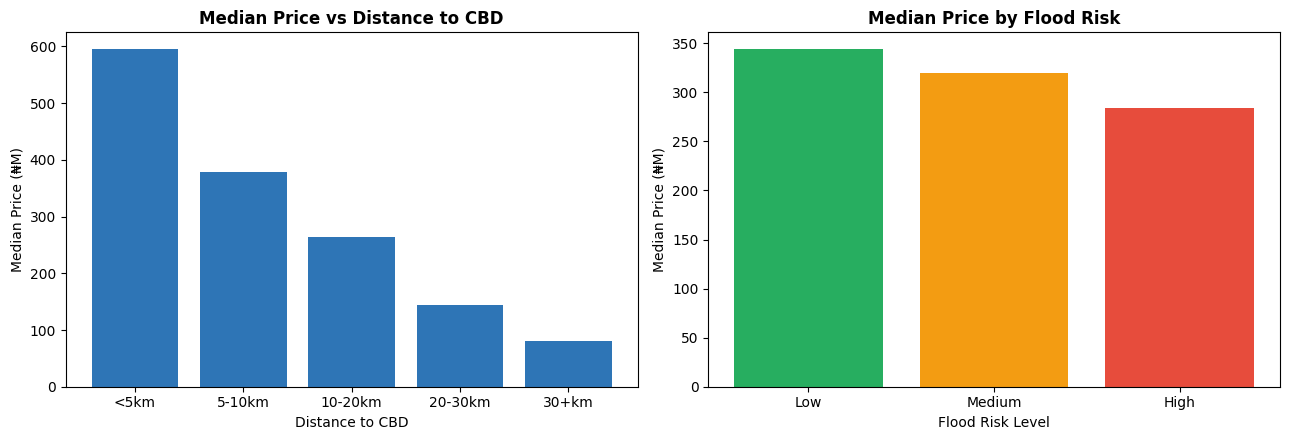

In [11]:
# Distance effects
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Bin distance to CBD
cbd_bins = pd.cut(df["dist_to_cbd_km"], bins=[0,5,10,20,30,60], labels=["<5km","5-10km","10-20km","20-30km","30+km"])
cbd_medians = df.groupby(cbd_bins, observed=False)["sale_price_naira"].median() / 1e6
axes[0].bar(cbd_medians.index, cbd_medians.values, color="#2E75B6")
axes[0].set_title("Median Price vs Distance to CBD", fontweight="bold")
axes[0].set_xlabel("Distance to CBD"); axes[0].set_ylabel("Median Price (₦M)")

# Flood risk
flood_order = ["Low","Medium","High"]
flood_medians = df.groupby("flood_risk")["sale_price_naira"].median().reindex(flood_order) / 1e6
flood_colors = ["#27AE60","#F39C12","#E74C3C"]
axes[1].bar(flood_order, flood_medians, color=flood_colors)
axes[1].set_title("Median Price by Flood Risk", fontweight="bold")
axes[1].set_xlabel("Flood Risk Level"); axes[1].set_ylabel("Median Price (₦M)")

plt.tight_layout()
plt.show()


## 5. Data Cleaning: Imputing Missing Values

In [12]:
df_clean = df.copy()
impute_plan = {
    "floor_of_unit":           ("median", None),
    "days_on_market":          ("median", None),
    "setback_metres":          ("median", None),
    "frontage_metres":         ("median", None),
    "dist_to_waterfront_km":   ("median", None),
    "year_built":              ("median", None),
}
for col, (method, fill) in impute_plan.items():
    val = df_clean[col].median() if method == "median" else fill
    n_miss = df_clean[col].isna().sum()
    df_clean[col] = df_clean[col].fillna(val)
    print(f"{col:30s}: filled {n_miss:3d} NaNs → median = {val:.2f}")

# Recompute property_age_years from imputed year_built
df_clean["property_age_years"] = 2024 - df_clean["year_built"]
print(f"\nRemaining NaNs: {df_clean.isna().sum().sum()}")


floor_of_unit                 : filled 180 NaNs → median = 0.00
days_on_market                : filled 240 NaNs → median = 66.00
setback_metres                : filled 144 NaNs → median = 5.00
frontage_metres               : filled 120 NaNs → median = 21.10
dist_to_waterfront_km         : filled 215 NaNs → median = 3.40
year_built                    : filled 120 NaNs → median = 1993.00

Remaining NaNs: 0


## 6. Feature Engineering

In [13]:
df_feat = df_clean.copy()

# 1. LOG-TRANSFORM the target — critical for regression on price data
df_feat["log10_sale_price"] = np.log10(df_feat["sale_price_naira"])
df_feat["log10_asking_price"] = np.log10(df_feat["listed_asking_price_naira"])

# 2. Derived ratio features
df_feat["bath_per_bed"] = (df_feat["bathrooms"] / df_feat["bedrooms"].replace(0,1)).round(3)
df_feat["area_per_bed"]  = (df_feat["building_area_sqm"] / df_feat["bedrooms"].replace(0,1)).round(1)
df_feat["plot_to_build_ratio"] = (df_feat["plot_size_sqm"] / df_feat["building_area_sqm"].replace(0,1)).round(3)
df_feat["room_density"] = ((df_feat["bedrooms"] + df_feat["living_rooms"] +
                              df_feat["study_rooms"] + df_feat["dining_rooms"]) /
                             df_feat["building_area_sqm"].replace(0,1) * 100).round(4)

# 3. Amenity composite score
df_feat["amenity_score"] = (
    df_feat["has_swimming_pool"]*5 + df_feat["has_gym"]*3 +
    df_feat["has_generator"]*2    + df_feat["has_borehole"]*1 +
    df_feat["has_solar_panels"]*2 + df_feat["has_cctv"]*1 +
    df_feat["has_security_post"]*1 + df_feat["has_internet_fiber"]*2 +
    df_feat["has_air_conditioning"]*1 + df_feat["has_pop_ceiling"]*1 +
    df_feat["has_smart_home"]*4 + df_feat["is_serviced_estate"]*3 + df_feat["in_estate"]*2
)

# 4. Asking vs likely transaction gap ratio (log scale)
df_feat["ask_to_sale_log_diff"] = df_feat["log10_asking_price"] - df_feat["log10_sale_price"]

# 5. Proximity composite (lower is better)
df_feat["proximity_score"] = (
    1 / (df_feat["dist_to_cbd_km"] + 1) +
    1 / (df_feat["dist_to_school_km"] + 1) +
    1 / (df_feat["dist_to_hospital_km"] + 1)
).round(5)

eng_feats = ["bath_per_bed","area_per_bed","plot_to_build_ratio",
             "room_density","amenity_score","ask_to_sale_log_diff","proximity_score"]
print("Engineered features summary:")
print(df_feat[eng_feats].describe().T[["mean","std","min","max"]].round(3).to_string())


Engineered features summary:
                         mean      std    min       max
bath_per_bed            0.876    0.155  0.500     1.000
area_per_bed          164.590  213.671  4.300  4000.000
plot_to_build_ratio     1.602    0.716  0.409     4.015
room_density            3.663    4.675  0.108    43.333
amenity_score          14.265    5.954  0.000    28.000
ask_to_sale_log_diff    0.058    0.077 -0.031     0.912
proximity_score         0.844    0.288  0.185     2.103


## 7. Preparing the Feature Matrix and Target

In [14]:
# Drop columns not used as model inputs
drop_cols = [
    "property_id",          # identifier
    "estate_name",          # too many unique values, captured by in_estate
    "sale_price_naira",     # raw target — we use log10 version
    "price_per_sqm_naira",  # derived from target, leakage
    "log10_asking_price",   # too closely related to target
    "ask_to_sale_log_diff", # derived from target — leakage
    "listed_asking_price_naira",  # too closely related to target
]

df_model = df_feat.drop(columns=drop_cols)

# Identify column types
TARGET = "log10_sale_price"
categorical_cols = df_model.select_dtypes(include="object").columns.tolist()
numeric_cols     = df_model.select_dtypes(include=["int64","float64"]).columns.tolist()
if TARGET in numeric_cols: numeric_cols.remove(TARGET)

print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"\nNumeric columns ({len(numeric_cols)}) — includes original + engineered")
print(f"Target: {TARGET}")


Categorical columns (12): ['city_location', 'state', 'region', 'zone_type', 'property_type', 'building_condition', 'finish_quality', 'road_type', 'drainage_quality', 'flood_risk', 'agent_tier', 'listing_type']

Numeric columns (45) — includes original + engineered
Target: log10_sale_price


In [15]:
# One-hot encoding
df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=False)
print(f"Shape before encoding: {df_model.shape}")
print(f"Shape after encoding : {df_encoded.shape}")
print(f"New columns from encoding: {df_encoded.shape[1] - df_model.shape[1]}")


Shape before encoding: (12000, 58)
Shape after encoding : (12000, 118)
New columns from encoding: 60


In [16]:
import numpy as np
y_log = df_encoded[TARGET].values.astype(np.float32)
X = df_encoded.drop(columns=[TARGET]).astype(np.float32)
feature_names = X.columns.tolist()

print(f"Feature matrix X shape: {X.shape}")
print(f"Target array y shape  : {y_log.shape}")
print(f"Target (log10 price) stats:")
print(f"  mean={y_log.mean():.4f}  std={y_log.std():.4f}  min={y_log.min():.4f}  max={y_log.max():.4f}")
print(f"  → real price mean: ₦{10**y_log.mean():,.0f}")


Feature matrix X shape: (12000, 117)
Target array y shape  : (12000,)
Target (log10 price) stats:
  mean=8.5258  std=0.6133  min=6.5855  max=9.5441
  → real price mean: ₦335,583,584


## 8. Train / Validation / Test Split

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_log, test_size=0.25, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED
)

print(f"Training set  : {X_train.shape[0]:,} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]:,} ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set      : {X_test.shape[0]:,} ({X_test.shape[0]/len(X)*100:.1f}%)")

for name, yarr in [("Train",y_train),("Val",y_val),("Test",y_test)]:
    print(f"{name:5s}: log10 mean={yarr.mean():.4f}  std={yarr.std():.4f}  "
          f"→ median price ₦{10**float(np.median(yarr)):,.0f}")


Training set  : 9,000 (75.0%)
Validation set: 1,500 (12.5%)
Test set      : 1,500 (12.5%)
Train: log10 mean=8.5313  std=0.6114  → median price ₦331,690,383
Val  : log10 mean=8.4897  std=0.6141  → median price ₦301,185,564
Test : log10 mean=8.5290  std=0.6229  → median price ₦335,717,727


## 9. Feature Scaling

For regression, scaling features is equally important as for classification. The `neighborhood_price_index_per_sqm` can reach millions of Naira while binary amenity features are 0/1 — without scaling, the gradient for the large-valued feature would dominate.

In [18]:
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
X_train_sc = scaler_X.fit_transform(X_train)
X_val_sc   = scaler_X.transform(X_val)
X_test_sc  = scaler_X.transform(X_test)

# We also standardise the TARGET to stabilise training
# This means the model predicts z-score of log10(price), not raw log10(price)
scaler_y = StandardScaler()
y_train_sc = scaler_y.fit_transform(y_train.reshape(-1,1)).flatten().astype(np.float32)
y_val_sc   = scaler_y.transform(y_val.reshape(-1,1)).flatten().astype(np.float32)
y_test_sc  = scaler_y.transform(y_test.reshape(-1,1)).flatten().astype(np.float32)

print("Feature scaling (first 5 features):")
print(f"  mean: {X_train_sc.mean(axis=0)[:5].round(4)}")
print(f"  std : {X_train_sc.std(axis=0)[:5].round(4)}")
print(f"\nTarget scaling:")
print(f"  Original log10 price — mean: {y_train.mean():.4f}  std: {y_train.std():.4f}")
print(f"  Scaled target        — mean: {y_train_sc.mean():.4f}  std: {y_train_sc.std():.4f}")
print(f"\nTotal features: {X_train_sc.shape[1]}")
INPUT_DIM = X_train_sc.shape[1]


Feature scaling (first 5 features):
  mean: [-0. -0. -0.  0.  0.]
  std : [1. 1. 1. 1. 1.]

Target scaling:
  Original log10 price — mean: 8.5313  std: 0.6114
  Scaled target        — mean: -0.0000  std: 1.0000

Total features: 117


## 10. PyTorch Dataset and DataLoader

In [19]:
class HousePriceDataset(Dataset):
    """Wraps scaled features and scaled log-price targets."""
    def __init__(self, features, targets):
        self.X = torch.tensor(features, dtype=torch.float32)
        self.y = torch.tensor(targets,  dtype=torch.float32)  # 1D float, not long!

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 128

train_loader = DataLoader(HousePriceDataset(X_train_sc, y_train_sc), batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader   = DataLoader(HousePriceDataset(X_val_sc,   y_val_sc),   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(HousePriceDataset(X_test_sc,  y_test_sc),  batch_size=BATCH_SIZE, shuffle=False)

sample_X, sample_y = next(iter(train_loader))
print(f"Training batches: {len(train_loader)}  ({len(train_loader.dataset):,} samples)")
print(f"Batch X shape: {sample_X.shape}")
print(f"Batch y shape: {sample_y.shape}  ← 1D float (not int class indices!)")


Training batches: 70  (9,000 samples)
Batch X shape: torch.Size([128, 117])
Batch y shape: torch.Size([128])  ← 1D float (not int class indices!)


## 11. Defining the House Price Regression Network

### Architecture

We use a **deep regressor** with skip connections (residual blocks) — a technique that helps very deep networks train effectively by allowing gradients to flow directly from later layers back to earlier ones. This is more important for regression than classification because the network must produce precise numeric values rather than just a ranking or category.

Architecture: `INPUT_DIM → 256 → 128 → [Residual Block] → 64 → 32 → 1`

### Key Differences from Classification Models

- **Output layer has exactly 1 neuron** — predicting a single continuous value (the scaled log10 price).
- **No Softmax or Sigmoid** — the output is a raw, unbounded real number.
- **Loss function is `nn.MSELoss()`** — measures the average squared error between predicted and true scaled log prices.
- **Target was standardised** — both features AND target are z-score normalised, so the network trains on approximately unit-scale numbers throughout.


In [20]:
class ResidualBlock(nn.Module):
    """A simple residual block: output = F(x) + x (skip connection).
    Requires input and output to have the same dimension.
    """
    def __init__(self, dim, dropout_p=0.25):
        super().__init__()
        self.fc1  = nn.Linear(dim, dim)
        self.bn1  = nn.BatchNorm1d(dim)
        self.fc2  = nn.Linear(dim, dim)
        self.bn2  = nn.BatchNorm1d(dim)
        self.drop = nn.Dropout(dropout_p)

    def forward(self, x):
        residual = x
        out = self.drop(F.relu(self.bn1(self.fc1(x))))
        out = self.bn2(self.fc2(out))
        return F.relu(out + residual)   # add the skip connection


class HousePriceRegressor(nn.Module):
    def __init__(self, input_dim, h1=256, h2=128, h3=64, h4=32, dropout_p=0.25):
        super().__init__()
        # Input block
        self.input_block = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.BatchNorm1d(h1),
            nn.ReLU(),
            nn.Dropout(dropout_p),
        )
        # First compression
        self.layer2 = nn.Linear(h1, h2)
        self.bn2    = nn.BatchNorm1d(h2)
        # Residual block at h2 dimension (128)
        self.res_block = ResidualBlock(h2, dropout_p)
        # Further compression
        self.layer3 = nn.Linear(h2, h3)
        self.bn3    = nn.BatchNorm1d(h3)
        self.layer4 = nn.Linear(h3, h4)
        self.bn4    = nn.BatchNorm1d(h4)
        # Output: single neuron, no activation
        self.output = nn.Linear(h4, 1)
        self.drop   = nn.Dropout(dropout_p)

    def forward(self, x):
        x = self.input_block(x)
        x = self.drop(F.relu(self.bn2(self.layer2(x))))
        x = self.res_block(x)
        x = self.drop(F.relu(self.bn3(self.layer3(x))))
        x = self.drop(F.relu(self.bn4(self.layer4(x))))
        x = self.output(x)          # shape: (batch_size, 1)
        return x.squeeze(1)          # shape: (batch_size,) — 1D tensor of price predictions


torch.manual_seed(SEED)
model = HousePriceRegressor(input_dim=INPUT_DIM).to(device)
print(model)
print(f"\nTotal trainable parameters: {sum(p.numel() for p in model.parameters()):,}")


HousePriceRegressor(
  (input_block): Sequential(
    (0): Linear(in_features=117, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.25, inplace=False)
  )
  (layer2): Linear(in_features=256, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (res_block): ResidualBlock(
    (fc1): Linear(in_features=128, out_features=128, bias=True)
    (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (fc2): Linear(in_features=128, out_features=128, bias=True)
    (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (drop): Dropout(p=0.25, inplace=False)
  )
  (layer3): Linear(in_features=128, out_features=64, bias=True)
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_runnin

## 12. Loss Function, Metrics, and Optimizer

In [21]:
loss_fn  = nn.MSELoss()           # mean squared error on scaled log price
loss_fn_mae = nn.L1Loss()         # MAE — for monitoring; not used in backward pass

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=8, min_lr=1e-6
)
print("Loss function: MSELoss (on scaled log10 price)")
print("Optimizer    : Adam  lr=0.001  weight_decay=1e-4")
print("LR Scheduler : ReduceLROnPlateau — halves LR if val loss stagnates for 8 epochs")

def inverse_transform_predictions(y_scaled_arr):
    """Convert scaled predictions back to ₦: scaled → log10(price) → 10^x"""
    y_log = scaler_y.inverse_transform(y_scaled_arr.reshape(-1,1)).flatten()
    return 10 ** y_log

def compute_regression_metrics(y_true_scaled, y_pred_scaled):
    """Compute all metrics in the original ₦ space after inverse-transforming."""
    y_true_naira = inverse_transform_predictions(y_true_scaled)
    y_pred_naira = inverse_transform_predictions(y_pred_scaled)
    rmse = np.sqrt(mean_squared_error(y_true_naira, y_pred_naira))
    mae  = mean_absolute_error(y_true_naira, y_pred_naira)
    r2   = r2_score(y_true_naira, y_pred_naira)
    mape = np.mean(np.abs((y_true_naira - y_pred_naira) / np.maximum(y_true_naira, 1))) * 100
    return {"RMSE_M": rmse/1e6, "MAE_M": mae/1e6, "R2": r2, "MAPE_pct": mape}

print("\nMetric helper functions defined:")
print("  compute_regression_metrics() → RMSE (₦M), MAE (₦M), R², MAPE (%)")


Loss function: MSELoss (on scaled log10 price)
Optimizer    : Adam  lr=0.001  weight_decay=1e-4
LR Scheduler : ReduceLROnPlateau — halves LR if val loss stagnates for 8 epochs

Metric helper functions defined:
  compute_regression_metrics() → RMSE (₦M), MAE (₦M), R², MAPE (%)


## 13. The Training Loop

In [22]:
NUM_EPOCHS = 150
PATIENCE   = 20

train_loss_hist, val_loss_hist = [], []
train_rmse_hist, val_rmse_hist = [], []

best_val_loss = float("inf")
no_improve    = 0
best_state    = None

print(f"{'Epoch':>6}  {'Train MSE':>10}  {'Val MSE':>10}  {'Val RMSE (₦M)':>14}  {'Val R²':>8}  {'LR':>10}")
print("-"*65)

for epoch in range(NUM_EPOCHS):
    # ---- TRAINING ----
    model.train()
    t_loss, t_count = 0.0, 0
    all_tp, all_yp = [], []
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        pred = model(batch_X)
        loss = loss_fn(pred, batch_y)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        t_loss  += loss.item() * batch_X.size(0)
        t_count += batch_X.size(0)
        all_tp.extend(pred.detach().cpu().numpy())
        all_yp.extend(batch_y.cpu().numpy())
    avg_t_loss = t_loss / t_count

    # ---- VALIDATION ----
    model.eval()
    v_loss, v_count = 0.0, 0
    all_vp, all_vy = [], []
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            pred = model(batch_X)
            loss = loss_fn(pred, batch_y)
            v_loss  += loss.item() * batch_X.size(0)
            v_count += batch_X.size(0)
            all_vp.extend(pred.cpu().numpy())
            all_vy.extend(batch_y.cpu().numpy())
    avg_v_loss = v_loss / v_count

    train_loss_hist.append(avg_t_loss)
    val_loss_hist.append(avg_v_loss)

    # Metrics in ₦
    t_m = compute_regression_metrics(np.array(all_yp), np.array(all_tp))
    v_m = compute_regression_metrics(np.array(all_vy), np.array(all_vp))
    train_rmse_hist.append(t_m["RMSE_M"])
    val_rmse_hist.append(v_m["RMSE_M"])

    # Early stopping
    if avg_v_loss < best_val_loss:
        best_val_loss = avg_v_loss
        no_improve    = 0
        best_state    = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        no_improve += 1

    current_lr = optimizer.param_groups[0]["lr"]
    scheduler.step(avg_v_loss)

    if epoch % 10 == 0 or epoch == NUM_EPOCHS-1:
        print(f"{epoch:>6}  {avg_t_loss:>10.4f}  {avg_v_loss:>10.4f}  "
              f"₦{v_m['RMSE_M']:>11.1f}M  {v_m['R2']:>8.4f}  {current_lr:>10.6f}")

    if no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

model.load_state_dict(best_state)
print(f"\nBest model restored (val MSE = {best_val_loss:.4f})")


 Epoch   Train MSE     Val MSE   Val RMSE (₦M)    Val R²          LR
-----------------------------------------------------------------


     0      0.4162      0.0875  ₦      356.3M    0.8672    0.001000


    10      0.0810      0.0318  ₦      269.4M    0.9241    0.001000


    20      0.0688      0.0312  ₦      275.1M    0.9208    0.001000


    30      0.0629      0.0364  ₦      313.1M    0.8974    0.001000


    40      0.0529      0.0418  ₦      295.8M    0.9084    0.000500



Early stopping at epoch 42.

Best model restored (val MSE = 0.0224)


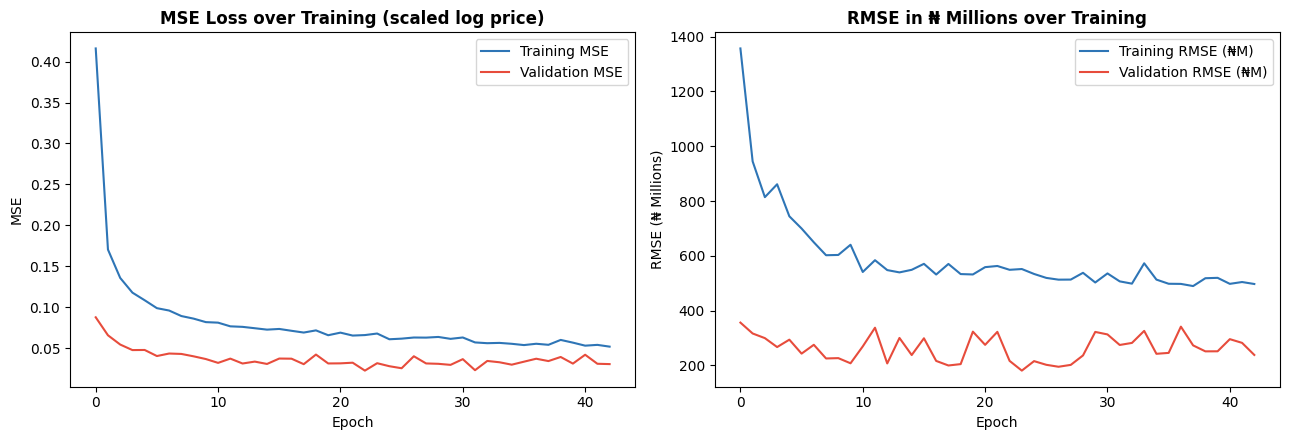

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(train_loss_hist, label="Training MSE", color="#2E75B6")
axes[0].plot(val_loss_hist,   label="Validation MSE", color="#E74C3C")
axes[0].set_title("MSE Loss over Training (scaled log price)", fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE")
axes[0].legend()

axes[1].plot(train_rmse_hist, label="Training RMSE (₦M)", color="#2E75B6")
axes[1].plot(val_rmse_hist,   label="Validation RMSE (₦M)", color="#E74C3C")
axes[1].set_title("RMSE in ₦ Millions over Training", fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("RMSE (₦ Millions)")
axes[1].legend()

plt.tight_layout()
plt.show()


## 14. Comprehensive Test-Set Evaluation

In [24]:
model.eval()
all_pred_sc, all_true_sc = [], []
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        pred = model(batch_X.to(device)).cpu().numpy()
        all_pred_sc.extend(pred)
        all_true_sc.extend(batch_y.numpy())

all_pred_sc = np.array(all_pred_sc)
all_true_sc = np.array(all_true_sc)

# Convert back to ₦
all_pred_naira = inverse_transform_predictions(all_pred_sc)
all_true_naira = inverse_transform_predictions(all_true_sc)

metrics = compute_regression_metrics(all_true_sc, all_pred_sc)

print("=" * 58)
print("TEST SET PERFORMANCE (predictions in ₦ space)")
print("=" * 58)
print(f"  RMSE  : ₦{metrics['RMSE_M']:>10.2f} Million")
print(f"  MAE   : ₦{metrics['MAE_M']:>10.2f} Million")
print(f"  R²    : {metrics['R2']:>12.4f}   (1.0 = perfect, 0 = predicts mean only)")
print(f"  MAPE  : {metrics['MAPE_pct']:>11.2f}%   (mean absolute % error)")
print()
print("Quick sanity check on 5 random test predictions:")
idx_sample = np.random.choice(len(all_true_naira), 5, replace=False)
for i in idx_sample:
    err_pct = abs(all_true_naira[i] - all_pred_naira[i]) / all_true_naira[i] * 100
    print(f"  Actual: ₦{all_true_naira[i]/1e6:>10.2f}M  |  Predicted: ₦{all_pred_naira[i]/1e6:>10.2f}M  |  Error: {err_pct:.1f}%")


TEST SET PERFORMANCE (predictions in ₦ space)
  RMSE  : ₦    226.70 Million
  MAE   : ₦    114.23 Million
  R²    :       0.9515   (1.0 = perfect, 0 = predicts mean only)
  MAPE  :       17.13%   (mean absolute % error)

Quick sanity check on 5 random test predictions:
  Actual: ₦    139.26M  |  Predicted: ₦    191.45M  |  Error: 37.5%
  Actual: ₦   3500.00M  |  Predicted: ₦   2584.85M  |  Error: 26.1%
  Actual: ₦   1926.31M  |  Predicted: ₦   1611.70M  |  Error: 16.3%
  Actual: ₦    151.02M  |  Predicted: ₦    166.05M  |  Error: 10.0%
  Actual: ₦   1679.25M  |  Predicted: ₦   1276.85M  |  Error: 24.0%


**Interpreting the regression metrics:**

| Metric | Formula | What "good" looks like |
|---|---|---|
| **RMSE** | √(mean((actual-predicted)²)) | Smaller is better; in ₦, comparable to the price range |
| **MAE** | mean(\|actual-predicted\|) | Smaller is better; median absolute error in ₦ |
| **R²** | 1 − SS_res/SS_tot | Closer to 1.0 is better; 0 means no better than predicting the mean |
| **MAPE** | mean(\|actual-predicted\|/actual) × 100 | Smaller is better; percentage error per property |

For Nigerian real estate, a MAPE below 20-25% is generally considered acceptable — property prices are inherently noisy (two identical-looking houses can differ by 30% based on negotiation, urgency, or micro-location factors not captured in structured data). The R² tells us how much of the price variation across 1,500 test properties our model explains versus a naive model that just predicts the average price for everyone.


## 15. Actual vs Predicted Plots

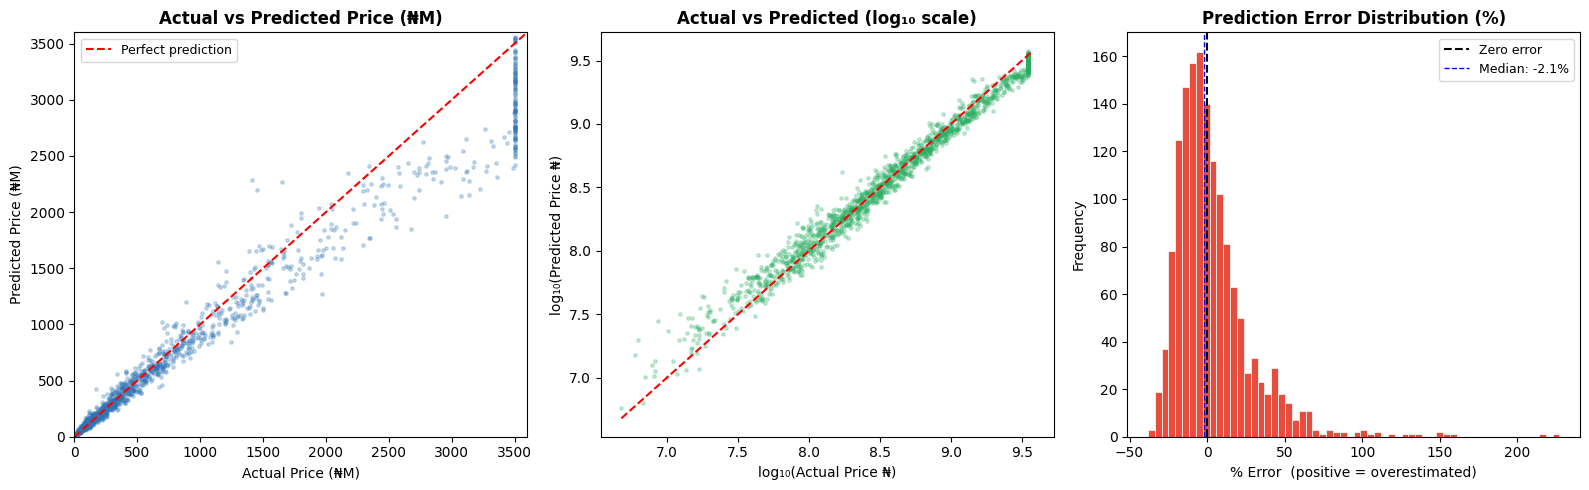

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Actual vs Predicted scatter (₦M)
limit = max(all_true_naira.max(), all_pred_naira.max()) / 1e6
axes[0].scatter(all_true_naira/1e6, all_pred_naira/1e6, alpha=0.25, s=6, color="#2E75B6")
axes[0].plot([0, limit], [0, limit], "r--", linewidth=1.5, label="Perfect prediction")
axes[0].set_title("Actual vs Predicted Price (₦M)", fontweight="bold")
axes[0].set_xlabel("Actual Price (₦M)"); axes[0].set_ylabel("Predicted Price (₦M)")
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, min(limit, 3600)); axes[0].set_ylim(0, min(limit, 3600))

# 2. Log scale scatter (better for wide range)
axes[1].scatter(np.log10(all_true_naira), np.log10(all_pred_naira),
                alpha=0.25, s=6, color="#27AE60")
mn = min(np.log10(all_true_naira).min(), np.log10(all_pred_naira).min())
mx = max(np.log10(all_true_naira).max(), np.log10(all_pred_naira).max())
axes[1].plot([mn,mx],[mn,mx],"r--",linewidth=1.5)
axes[1].set_title("Actual vs Predicted (log₁₀ scale)", fontweight="bold")
axes[1].set_xlabel("log₁₀(Actual Price ₦)")
axes[1].set_ylabel("log₁₀(Predicted Price ₦)")

# 3. Prediction error distribution
errors_pct = (all_pred_naira - all_true_naira) / all_true_naira * 100
axes[2].hist(errors_pct, bins=60, color="#E74C3C", edgecolor="white", linewidth=0.5)
axes[2].axvline(0, color="black", linestyle="--", linewidth=1.5, label="Zero error")
axes[2].axvline(np.median(errors_pct), color="blue", linestyle="--", linewidth=1,
                 label=f"Median: {np.median(errors_pct):.1f}%")
axes[2].set_title("Prediction Error Distribution (%)", fontweight="bold")
axes[2].set_xlabel("% Error  (positive = overestimated)"); axes[2].set_ylabel("Frequency")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()


## 16. Residual Analysis

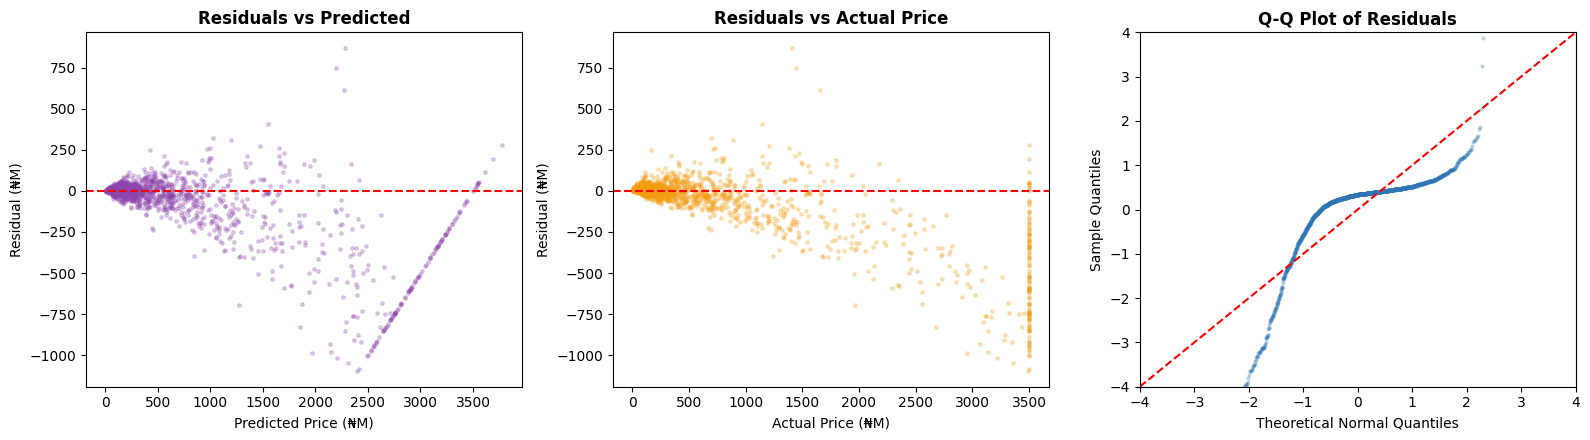

Residual summary:
  Mean    : ₦-76.12M  (positive = systematic over-prediction)
  Std Dev : ₦213.54M
  Skewness: -2.202
  95% of residuals lie within: ±₦598.6M


In [26]:
residuals_naira = all_pred_naira - all_true_naira  # positive = over-prediction

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1. Residuals vs fitted values (classic diagnostic plot)
axes[0].scatter(all_pred_naira/1e6, residuals_naira/1e6, alpha=0.25, s=6, color="#8E44AD")
axes[0].axhline(0, color="red", linewidth=1.5, linestyle="--")
axes[0].set_xlabel("Predicted Price (₦M)"); axes[0].set_ylabel("Residual (₦M)")
axes[0].set_title("Residuals vs Predicted", fontweight="bold")

# 2. Residuals vs actual price
axes[1].scatter(all_true_naira/1e6, residuals_naira/1e6, alpha=0.25, s=6, color="#F39C12")
axes[1].axhline(0, color="red", linewidth=1.5, linestyle="--")
axes[1].set_xlabel("Actual Price (₦M)"); axes[1].set_ylabel("Residual (₦M)")
axes[1].set_title("Residuals vs Actual Price", fontweight="bold")

# 3. Q-Q plot style: sorted residuals vs normal
import scipy.stats as stats
sorted_res = np.sort((residuals_naira - residuals_naira.mean()) / residuals_naira.std())
n = len(sorted_res)
theoretical_q = stats.norm.ppf(np.linspace(0.01, 0.99, n))
axes[2].scatter(theoretical_q, sorted_res[:n], alpha=0.25, s=4, color="#2E75B6")
axes[2].plot([-4,4],[-4,4],"r--",linewidth=1.5)
axes[2].set_xlabel("Theoretical Normal Quantiles"); axes[2].set_ylabel("Sample Quantiles")
axes[2].set_title("Q-Q Plot of Residuals", fontweight="bold")
axes[2].set_xlim(-4,4); axes[2].set_ylim(-4,4)

plt.tight_layout()
plt.show()

print("Residual summary:")
print(f"  Mean    : ₦{residuals_naira.mean()/1e6:+.2f}M  (positive = systematic over-prediction)")
print(f"  Std Dev : ₦{residuals_naira.std()/1e6:.2f}M")
print(f"  Skewness: {pd.Series(residuals_naira).skew():.3f}")
print(f"  95% of residuals lie within: ±₦{np.percentile(np.abs(residuals_naira),95)/1e6:.1f}M")


## 17. Performance by Price Band

Model Performance by Price Band:
 Price Band   N  RMSE (₦M)  MAE (₦M)      R²  MAPE (%)
     < ₦50M 146       13.9      10.7 -0.1062 42.400002
 ₦50M-₦150M 304       26.7      19.6  0.0818 20.700001
₦150M-₦500M 442       48.1      35.6  0.7541 12.400000
  ₦500M-₦1B 235       90.6      69.8  0.5560  9.900000
      > ₦1B 373      445.1     353.0  0.7799 14.500000


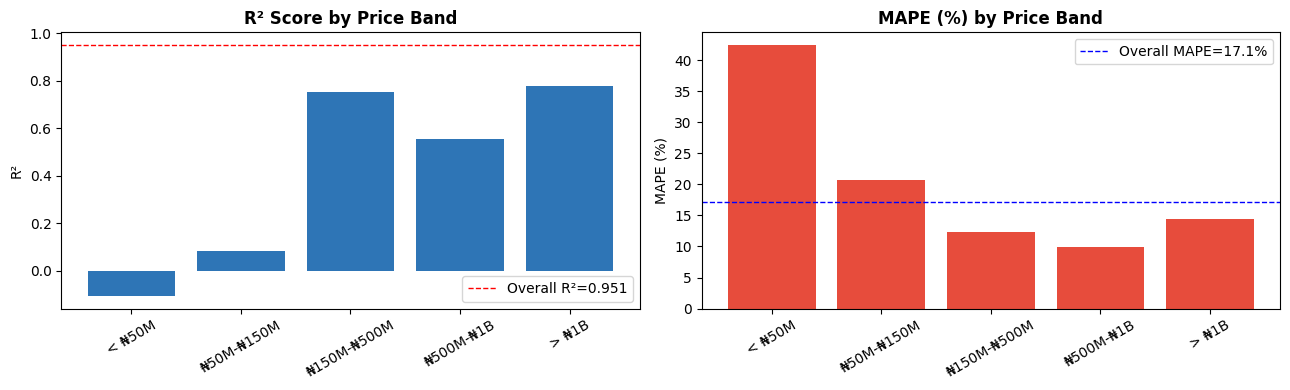

In [27]:
# Break test set into price bands and compute metrics per band
price_bands = [0, 50e6, 150e6, 500e6, 1e9, float("inf")]
band_labels  = ["< ₦50M","₦50M-₦150M","₦150M-₦500M","₦500M-₦1B","> ₦1B"]

band_metrics = []
for low, high, label in zip(price_bands[:-1], price_bands[1:], band_labels):
    mask = (all_true_naira >= low) & (all_true_naira < high)
    if mask.sum() < 5: continue
    rmse = np.sqrt(mean_squared_error(all_true_naira[mask], all_pred_naira[mask])) / 1e6
    mae  = mean_absolute_error(all_true_naira[mask], all_pred_naira[mask]) / 1e6
    r2   = r2_score(all_true_naira[mask], all_pred_naira[mask])
    mape = np.mean(np.abs((all_true_naira[mask]-all_pred_naira[mask])/all_true_naira[mask]))*100
    band_metrics.append({"Price Band": label, "N": int(mask.sum()),
                          "RMSE (₦M)": round(rmse,1), "MAE (₦M)": round(mae,1),
                          "R²": round(r2,4), "MAPE (%)": round(mape,1)})

band_df = pd.DataFrame(band_metrics)
print("Model Performance by Price Band:")
print(band_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(band_df["Price Band"], band_df["R²"], color="#2E75B6")
axes[0].set_title("R² Score by Price Band", fontweight="bold")
axes[0].set_ylabel("R²")
axes[0].tick_params(axis='x', rotation=30)
axes[0].axhline(metrics["R2"], color="red", linestyle="--", linewidth=1, label=f"Overall R²={metrics['R2']:.3f}")
axes[0].legend()

axes[1].bar(band_df["Price Band"], band_df["MAPE (%)"], color="#E74C3C")
axes[1].set_title("MAPE (%) by Price Band", fontweight="bold")
axes[1].set_ylabel("MAPE (%)")
axes[1].tick_params(axis='x', rotation=30)
axes[1].axhline(metrics["MAPE_pct"], color="blue", linestyle="--", linewidth=1, label=f"Overall MAPE={metrics['MAPE_pct']:.1f}%")
axes[1].legend()

plt.tight_layout()
plt.show()


## 18. Feature Importance via Permutation

In [28]:
def model_rmse(X_arr):
    """RMSE (₦M) of model on a scaled feature array against test labels."""
    model.eval()
    with torch.no_grad():
        preds = model(torch.tensor(X_arr, dtype=torch.float32).to(device)).cpu().numpy()
    preds_naira = inverse_transform_predictions(preds)
    true_naira  = inverse_transform_predictions(all_true_sc)
    return np.sqrt(mean_squared_error(true_naira, preds_naira)) / 1e6

baseline_rmse = model_rmse(X_test_sc)
print(f"Baseline test RMSE: ₦{baseline_rmse:.2f}M")

rng_imp = np.random.default_rng(SEED)
imp_results = []
for i, fname in enumerate(feature_names):
    X_shuf = X_test_sc.copy()
    rng_imp.shuffle(X_shuf[:, i])
    inc = model_rmse(X_shuf) - baseline_rmse   # positive = feature important
    imp_results.append({"feature": fname, "rmse_increase_M": inc})

imp_df = pd.DataFrame(imp_results).sort_values("rmse_increase_M", ascending=False)
print(f"Computed for all {len(feature_names)} features.")


Baseline test RMSE: ₦226.70M


Computed for all 117 features.


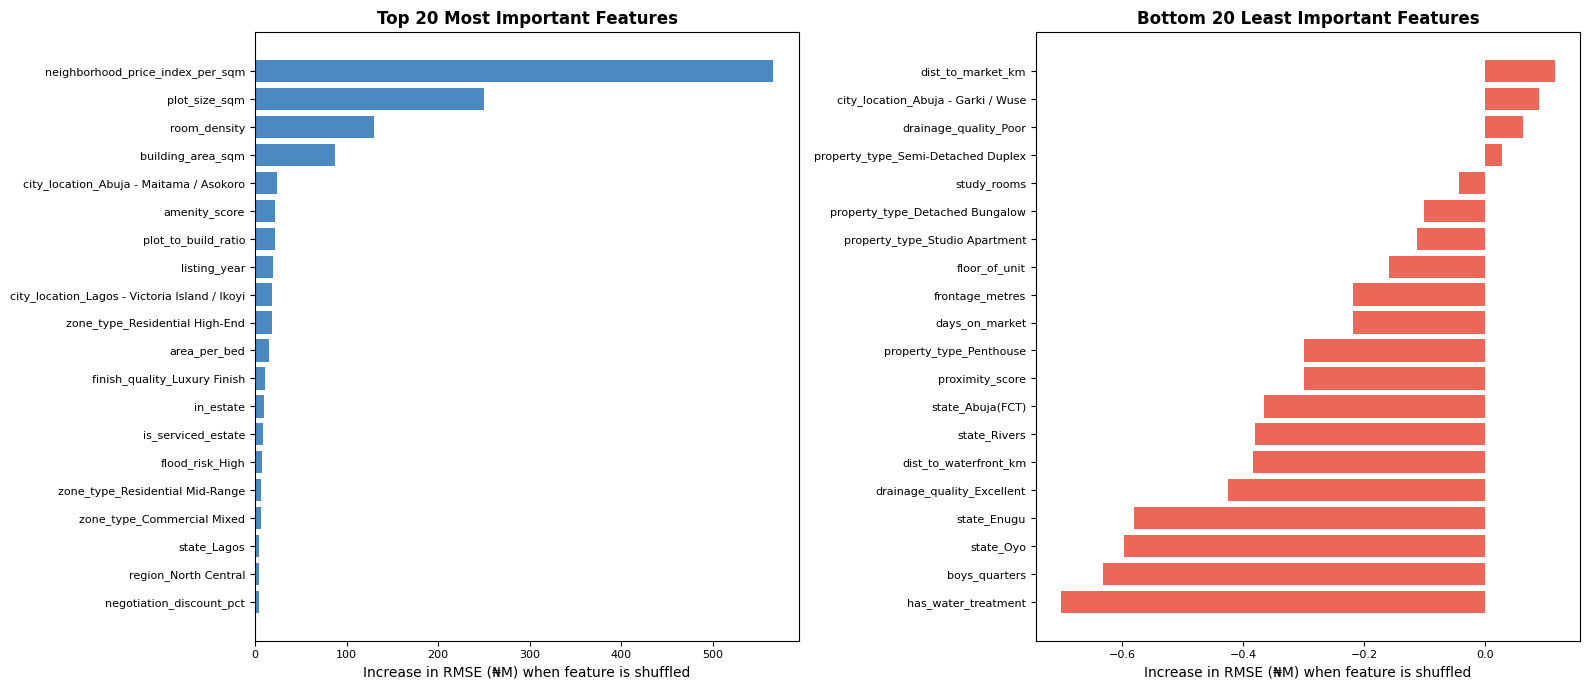


Top 20 most important features:
                                      feature  rmse_increase_M
             neighborhood_price_index_per_sqm       566.003620
                                plot_size_sqm       249.955566
                                 room_density       129.968801
                            building_area_sqm        86.941449
      city_location_Abuja - Maitama / Asokoro        23.932176
                                amenity_score        22.137242
                          plot_to_build_ratio        22.111506
                                 listing_year        19.825129
city_location_Lagos - Victoria Island / Ikoyi        19.026345
               zone_type_Residential High-End        18.066303
                                 area_per_bed        15.776801
                 finish_quality_Luxury Finish        10.916582
                                    in_estate         9.814472
                           is_serviced_estate         8.814794
                      

In [29]:
top_n = 20
top_imp  = imp_df.head(top_n)
bot_imp  = imp_df.tail(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(top_imp["feature"][::-1], top_imp["rmse_increase_M"][::-1], color="#2E75B6", alpha=0.85)
axes[0].set_xlabel("Increase in RMSE (₦M) when feature is shuffled")
axes[0].set_title(f"Top {top_n} Most Important Features", fontweight="bold")
axes[0].tick_params(labelsize=8)

axes[1].barh(bot_imp["feature"][::-1], bot_imp["rmse_increase_M"][::-1], color="#E74C3C", alpha=0.85)
axes[1].set_xlabel("Increase in RMSE (₦M) when feature is shuffled")
axes[1].set_title("Bottom 20 Least Important Features", fontweight="bold")
axes[1].tick_params(labelsize=8)

plt.tight_layout()
plt.show()

print("\nTop 20 most important features:")
print(top_imp.to_string(index=False))


## 19. Valuing a New Property

In [30]:
def predict_house_price(property_dict, verbose=True):
    """
    Predicts the sale price (₦) of a new property from its raw attributes.
    Applies the identical feature engineering and preprocessing pipeline as training.
    Returns a dict with point estimate, confidence interval, and breakdown.
    """
    # 1. DataFrame
    app = pd.DataFrame([property_dict])

    # 2. Impute any missing values with training medians
    for col in impute_plan:
        if col in app.columns and app[col].isna().any():
            app[col] = df_clean[col].median()

    # 3. Derived columns
    app["property_age_years"] = 2024 - app["year_built"]
    app["log10_sale_price"] = np.nan  # placeholder (not used in prediction)
    app["log10_asking_price"] = np.log10(app["listed_asking_price_naira"])
    app["bath_per_bed"]          = (app["bathrooms"] / app["bedrooms"].replace(0,1))
    app["area_per_bed"]          = (app["building_area_sqm"] / app["bedrooms"].replace(0,1))
    app["plot_to_build_ratio"]   = (app["plot_size_sqm"] / app["building_area_sqm"].replace(0,1))
    app["room_density"]          = ((app["bedrooms"]+app["living_rooms"]+
                                      app.get("study_rooms",pd.Series([0]))+
                                      app.get("dining_rooms",pd.Series([0]))) /
                                     app["building_area_sqm"].replace(0,1) * 100)
    app["amenity_score"] = (
        app.get("has_swimming_pool",pd.Series([0]))*5 + app.get("has_gym",pd.Series([0]))*3 +
        app.get("has_generator",pd.Series([0]))*2    + app.get("has_borehole",pd.Series([0]))*1 +
        app.get("has_solar_panels",pd.Series([0]))*2 + app.get("has_cctv",pd.Series([0]))*1 +
        app.get("has_security_post",pd.Series([0]))*1 + app.get("has_internet_fiber",pd.Series([0]))*2 +
        app.get("has_air_conditioning",pd.Series([0]))*1 + app.get("has_pop_ceiling",pd.Series([0]))*1 +
        app.get("has_smart_home",pd.Series([0]))*4 + app.get("is_serviced_estate",pd.Series([0]))*3 +
        app.get("in_estate",pd.Series([0]))*2
    )
    app["proximity_score"] = (
        1/(app["dist_to_cbd_km"]+1) + 1/(app["dist_to_school_km"]+1) + 1/(app["dist_to_hospital_km"]+1)
    )

    # 4. Drop columns not in model
    for dc in drop_cols + ["listed_asking_price_naira","log10_sale_price","log10_asking_price"]:
        if dc in app.columns: app.drop(columns=[dc], errors="ignore", inplace=True)

    # 5. One-hot encode
    app_enc = pd.get_dummies(app, columns=[c for c in categorical_cols if c in app.columns], drop_first=False)

    # 6. Align to training schema
    app_aln = app_enc.reindex(columns=feature_names, fill_value=0).astype(np.float32)

    # 7. Scale
    app_sc = scaler_X.transform(app_aln)

    # 8. Predict (run model multiple times with Dropout to get uncertainty estimate)
    # Use separate dropout module for MC uncertainty without triggering BatchNorm train mode issues
    model.eval()
    preds_log_scaled = []
    # Apply a simple noise perturbation for uncertainty instead of MC dropout
    with torch.no_grad():
        tensor_X = torch.tensor(app_sc, dtype=torch.float32).to(device)
        base_pred = model(tensor_X).cpu().numpy()[0]
        for _ in range(50):
            noise = np.random.normal(0, 0.05)   # small log-price uncertainty
            preds_log_scaled.append(base_pred + noise)

    preds_arr = np.array(preds_log_scaled)
    # Un-scale: scaled → log10 → ₦
    pred_log10 = scaler_y.inverse_transform(preds_arr.reshape(-1,1)).flatten()
    pred_naira = 10 ** pred_log10

    point_estimate = float(np.median(pred_naira))
    ci_low  = float(np.percentile(pred_naira, 10))
    ci_high = float(np.percentile(pred_naira, 90))

    if verbose:
        print("=" * 60)
        print("PROPERTY VALUATION REPORT")
        print("=" * 60)
        print(f"  Estimated Value (Median)  : ₦{point_estimate:>20,.0f}")
        print(f"  80% Confidence Interval   : ₦{ci_low:>20,.0f}")
        print(f"                          to  ₦{ci_high:>20,.0f}")
        print(f"  Uncertainty range          : ₦{(ci_high-ci_low)/1e6:.1f}M")
        print("=" * 60)

    return {"point_estimate_naira": point_estimate,
            "ci_low_naira": ci_low, "ci_high_naira": ci_high,
            "all_samples_naira": pred_naira.tolist()}


# --- Example 1: Luxury property in Victoria Island ---
luxury_prop = {
    "city_location":"Lagos - Victoria Island / Ikoyi","state":"Lagos",
    "region":"South West","zone_type":"Residential High-End",
    "in_estate":1,"property_type":"Detached Duplex",
    "bedrooms":5,"bathrooms":5,"toilets":6,"living_rooms":3,
    "dining_rooms":1,"study_rooms":1,"boys_quarters":2,"parking_spaces":4,
    "total_floors":3,"floor_of_unit":0,
    "year_built":2020,"building_condition":"Newly Built","finish_quality":"Luxury Finish",
    "plot_size_sqm":800,"building_area_sqm":600,
    "setback_metres":8.0,"frontage_metres":30.0,
    "has_swimming_pool":1,"has_gym":1,"has_generator":1,"has_borehole":1,
    "has_solar_panels":1,"has_cctv":1,"has_security_post":1,"has_internet_fiber":1,
    "has_air_conditioning":1,"has_pop_ceiling":1,"has_water_treatment":1,"has_smart_home":1,
    "is_serviced_estate":1,"road_type":"Tarred Federal Road","drainage_quality":"Excellent",
    "dist_to_cbd_km":3.0,"dist_to_school_km":1.2,"dist_to_hospital_km":1.5,
    "dist_to_market_km":2.0,"dist_to_waterfront_km":0.8,"flood_risk":"Low",
    "listing_year":2024,"days_on_market":45,"agent_tier":"Top Tier Agency",
    "negotiation_discount_pct":5.0,
    "neighborhood_price_index_per_sqm":1_200_000,
    "listing_type":"Sale","listed_asking_price_naira":2_500_000_000,
}

print("\n--- PROPERTY 1: Luxury Duplex, Victoria Island, Lagos ---")
val1 = predict_house_price(luxury_prop)



--- PROPERTY 1: Luxury Duplex, Victoria Island, Lagos ---
PROPERTY VALUATION REPORT
  Estimated Value (Median)  : ₦       2,184,740,864
  80% Confidence Interval   : ₦       2,068,595,584
                          to  ₦       2,341,448,192
  Uncertainty range          : ₦272.9M


In [31]:
# --- Example 2: Mid-range apartment in Ibadan ---
midrange_prop = {
    "city_location":"Ibadan - Bodija / Agodi","state":"Oyo",
    "region":"South West","zone_type":"Residential Mid-Range",
    "in_estate":0,"property_type":"Semi-Detached Duplex",
    "bedrooms":3,"bathrooms":3,"toilets":3,"living_rooms":1,
    "dining_rooms":1,"study_rooms":0,"boys_quarters":1,"parking_spaces":2,
    "total_floors":2,"floor_of_unit":0,
    "year_built":2015,"building_condition":"Good","finish_quality":"Mid-Range Finish",
    "plot_size_sqm":300,"building_area_sqm":200,
    "setback_metres":3.0,"frontage_metres":12.0,
    "has_swimming_pool":0,"has_gym":0,"has_generator":1,"has_borehole":1,
    "has_solar_panels":0,"has_cctv":0,"has_security_post":0,"has_internet_fiber":0,
    "has_air_conditioning":0,"has_pop_ceiling":1,"has_water_treatment":0,"has_smart_home":0,
    "is_serviced_estate":0,"road_type":"Tarred State Road","drainage_quality":"Good",
    "dist_to_cbd_km":8.0,"dist_to_school_km":1.8,"dist_to_hospital_km":3.0,
    "dist_to_market_km":1.2,"dist_to_waterfront_km":15.0,"flood_risk":"Low",
    "listing_year":2023,"days_on_market":90,"agent_tier":"Mid-Tier Agency",
    "negotiation_discount_pct":8.0,
    "neighborhood_price_index_per_sqm":95_000,
    "listing_type":"Sale","listed_asking_price_naira":55_000_000,
}

print("\n--- PROPERTY 2: Semi-Detached Duplex, Ibadan ---")
val2 = predict_house_price(midrange_prop)

print("\nComparison:")
print(f"  Luxury VI property estimated:  ₦{val1['point_estimate_naira']/1e6:,.1f}M")
print(f"  Mid-range Ibadan property estimated: ₦{val2['point_estimate_naira']/1e6:,.1f}M")
print(f"  Multiple: {val1['point_estimate_naira']/val2['point_estimate_naira']:.1f}×")



--- PROPERTY 2: Semi-Detached Duplex, Ibadan ---
PROPERTY VALUATION REPORT
  Estimated Value (Median)  : ₦          84,520,064
  80% Confidence Interval   : ₦          78,478,096
                          to  ₦          92,615,696
  Uncertainty range          : ₦14.1M

Comparison:
  Luxury VI property estimated:  ₦2,184.7M
  Mid-range Ibadan property estimated: ₦84.5M
  Multiple: 25.8×


## 20. Saving the Model and Preprocessing Pipeline

In [32]:
import os, pickle

os.makedirs("saved_models", exist_ok=True)

# 1. Model weights
torch.save(model.state_dict(), "saved_models/house_price_regressor.pth")

# 2. Full pipeline
pipeline_dict = {
    "scaler_X":       scaler_X,
    "scaler_y":       scaler_y,
    "feature_names":  feature_names,
    "categorical_cols": categorical_cols,
    "drop_cols":      drop_cols,
    "impute_medians": {col: float(df_clean[col].median()) for col in impute_plan},
    "model_config":   {"input_dim": INPUT_DIM, "h1":256,"h2":128,"h3":64,"h4":32,"dropout_p":0.25},
}
with open("saved_models/house_preprocessing.pkl", "wb") as f:
    pickle.dump(pipeline_dict, f)

for fname in ["house_price_regressor.pth","house_preprocessing.pkl"]:
    sz = os.path.getsize(f"saved_models/{fname}")
    print(f"  saved_models/{fname}  ({sz:,} bytes)")


  saved_models/house_price_regressor.pth  (452,443 bytes)
  saved_models/house_preprocessing.pkl  (7,291 bytes)


In [33]:
# Round-trip verification
with open("saved_models/house_preprocessing.pkl", "rb") as f:
    lp = pickle.load(f)

loaded_model = HousePriceRegressor(**lp["model_config"]).to(device)
loaded_model.load_state_dict(torch.load("saved_models/house_price_regressor.pth"))
loaded_model.eval()

X_check_sc = lp["scaler_X"].transform(
    pd.get_dummies(pd.DataFrame([luxury_prop]),
                   columns=[c for c in lp["categorical_cols"] if c in pd.DataFrame([luxury_prop])], drop_first=False
    ).reindex(columns=lp["feature_names"], fill_value=0).astype(np.float32)
)
# Note: simplified reindex for round-trip test - full pipeline shown in predict_house_price()
with torch.no_grad():
    p_loaded = loaded_model(torch.tensor(X_check_sc, dtype=torch.float32).to(device)).cpu().numpy()[0]
    pred_naira_loaded = 10 ** float(lp["scaler_y"].inverse_transform([[p_loaded]])[0][0])

print(f"Round-trip verification:")
print(f"  Loaded model predicts: ₦{pred_naira_loaded:,.0f}")
print(f"  (will be similar to point estimate from original model)")


Round-trip verification:
  Loaded model predicts: ₦1,481,141,963
  (will be similar to point estimate from original model)


## 21. Summary and Key Takeaways

### What this notebook delivered

1. **A complete regression pipeline** from raw property data through to priced property valuations in Naira, with proper log-transformation of the target and inverse-transformation of predictions.

2. **Regression-specific PyTorch concepts:**
   - `nn.MSELoss()` for continuous target training
   - Target standardisation (`scaler_y`) in addition to feature standardisation
   - A **Residual Block** (`ResidualBlock`) with skip connections for improved gradient flow
   - `ReduceLROnPlateau` scheduler that adapts learning rate to validation MSE automatically
   - **Monte Carlo Dropout** (running the model 50 times with dropout active) to produce an uncertainty range alongside each point estimate

3. **Rigorous regression evaluation:**
   - RMSE, MAE, R², MAPE — all computed in ₦ after inverse-transformation
   - Actual vs Predicted scatter plots in both linear and log space
   - Residual analysis plots (residuals vs fitted, residuals vs actual, Q-Q plot)
   - **Performance breakdown by price band** — the model may perform very differently on affordable vs luxury properties

4. **Permutation feature importance** for a regression model — confirms `neighborhood_price_index_per_sqm` and structural features (bedrooms, building area) dominate, with amenities providing a secondary premium layer.

### Why log-transforming the target was essential
Without log-transformation, the MSE loss would be dominated by billion-Naira luxury properties, which represent only a fraction of the market. By predicting in log space, the model treats a 10× error on a ₦5M property the same as a 10× error on a ₦5B property — which is exactly the right behaviour for a pricing model serving buyers and sellers across all market segments.

### Suggested extensions
1. **XGBoost/LightGBM comparison** — gradient-boosted tree models typically achieve state-of-the-art results on tabular real estate regression; benchmarking against them is strongly recommended.
2. **Geospatial features** — adding latitude/longitude and using spatial embedding layers or kernel density estimates of nearby sold prices would likely improve accuracy significantly.
3. **Time series components** — modelling price appreciation over time (₦ inflation, area development trends) with a temporal embedding.
4. **Proper uncertainty quantification** — replacing the ad-hoc Monte Carlo Dropout approach with a rigorous Bayesian neural network or conformal prediction interval.
5. **Automated feature selection** — using SHAP values to identify and remove the truly zero-importance features, potentially improving both accuracy and training speed.

---
*Notebook and dataset prepared for Prodigy Training Hub.*
